# DodoGo - User Survival, Cohort Retention and First-Trip Return (NB04)

This notebook supports Sections 3.3.1, 3.3.4 and 3.3.5. It focuses on the customer lifecycle: what happens after the first order, how quickly users become inactive and how local, tourist-SIM and international users differ.


In [ ]:
!pip install lifelines

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from lifelines import KaplanMeierFitter
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

C = {'primary':'#1565C0','secondary':'#FF5722','success':'#4CAF50',
     'warning':'#FF9800','danger':'#E53935','purple':'#9C27B0','gray':'#9E9E9E',
     'tourist':'#E91E63'}
plt.rcParams.update({'figure.figsize':(14,8),'font.size':11,'figure.facecolor':'white',
    'axes.facecolor':'#FAFAFA','axes.grid':True,'grid.alpha':0.3,'figure.dpi':120})
print("Libraries loaded.")


In [ ]:
df = pd.read_csv("../data/raw/orders_new_platform.csv", sep=";", encoding="windows-1251", low_memory=False)
df['created'] = pd.to_datetime(df['Дата создания'], format="%d.%m.%Y %H:%M", errors='coerce')
for col in ['Стоимость','Суммарное расстояние (км)']:
    df[col] = df[col].astype(str).str.replace(',','.').astype(float)
df.rename(columns={'Стоимость':'price','Суммарное расстояние (км)':'distance_km',
    'Текущий статус':'status','Тариф':'tariff','Способ заказа':'order_source',
    'Исполнитель':'driver','Телефон клиента':'client_phone','Адрес подачи':'pickup_address'}, inplace=True)
df['is_completed'] = df['status'].str.contains('Выполнен', na=False)
df['hour'] = df['created'].dt.hour
df['day_of_week'] = df['created'].dt.dayofweek
df['date'] = pd.to_datetime(df['created'].dt.date)
comp = df[df['is_completed']&(df['price']>0)].copy()
max_date = comp['date'].max()

def classify_type(phone):
    p = str(phone)
    if p.startswith('2307'): return 'Tourist SIM'
    if p.startswith('230'): return 'Local'
    return 'International'

def classify_country(phone):
    p = str(phone)
    if p.startswith('2307'): return 'Tourist SIM (+2307)'
    if p.startswith('230'): return 'Local (Mauritius)'
    if p.startswith('33'): return 'France'
    if p.startswith('44'): return 'UK'
    if p.startswith('262'): return 'Réunion'
    if p.startswith('49'): return 'Germany'
    if p.startswith('79') or p.startswith('78'): return 'Russia'
    if p.startswith('91'): return 'India'
    if p.startswith('41'): return 'Switzerland'
    if p.startswith('27'): return 'South Africa'
    return 'Other Intl'

user = comp.groupby('client_phone').agg(
    first_date=('date','min'), last_date=('date','max'),
    trips=('price','count'), total_spent=('price','sum'),
    avg_price=('price','mean'), avg_distance=('distance_km', lambda x: x[x>0].mean()),
    avg_hour=('hour','mean'), weekend_ratio=('day_of_week', lambda x: (x>=5).mean()),
    unique_days=('date','nunique'))
user['tenure_days'] = (user['last_date'] - user['first_date']).dt.days
user['days_since_last'] = (max_date - user['last_date']).dt.days
user['user_type'] = user.index.map(classify_type)
user['country'] = user.index.map(classify_country)
user['is_local'] = user['user_type'] == 'Local'
user['is_tourist_sim'] = user['user_type'] == 'Tourist SIM'
user['is_international'] = user['user_type'] == 'International'
user['is_tourist_any'] = ~user['is_local']  # all non-locals
user['is_churned'] = (user['days_since_last'] > 30).astype(int)
user['returned'] = (user['trips'] >= 2).astype(int)

first_trip = comp.sort_values('created').groupby('client_phone').first()
user['first_price'] = first_trip['price']
user['first_distance'] = first_trip['distance_km']
user['first_hour'] = first_trip['hour']
user['first_dow'] = first_trip['day_of_week']
user['first_weekend'] = (user['first_dow'] >= 5).astype(int)

f3 = df.sort_values('created').groupby('client_phone').head(3)
user = user.join(f3.groupby('client_phone')['is_completed'].mean().rename('first3_success'), how='left')
user['first3_success'] = user['first3_success'].fillna(0.5)

fw = comp.merge(user[['first_date']], left_on='client_phone', right_index=True)
fw['d'] = (fw['date'] - fw['first_date']).dt.days
user = user.join(fw[fw['d']<=7].groupby('client_phone').size().rename('w1_trips'), how='left')
user['w1_trips'] = user['w1_trips'].fillna(1).astype(int)

print("=" * 60)
print("USER BASE COMPOSITION (UPDATED)")
print("=" * 60)
for t in ['Local','Tourist SIM','International']:
    u = user[user['user_type']==t]
    print(f"\n{t}: {len(u):,} users ({len(u)/len(user)*100:.1f}%)")
    print(f"  Avg trips: {u['trips'].mean():.1f} | Avg price: {u['avg_price'].mean():.0f} MUR | "
          f"Return: {u['returned'].mean()*100:.0f}% | Churn: {u['is_churned'].mean()*100:.0f}%")

print(f"\nTotal tourists (SIM + Intl): {user['is_tourist_any'].sum():,} ({user['is_tourist_any'].mean()*100:.1f}%)")


USER BASE COMPOSITION SUMMARY
Local users: 12,053 (69.5%), average trip frequency 3.8, return rate 55%, churn rate 72%.
Tourist SIM users: 1,796 (10.4%), average trip frequency 4.0, return rate 68%, churn rate 82%.
International users: 3,503 (20.2%), average trip frequency 2.9, return rate 59%, churn rate 80%.
Total tourist-related users: 5,299 (30.5%). Exact average fare values are omitted from the public output.


### Segment Definition Note

Users are grouped into local, tourist-SIM and international segments using phone-origin information. The split is used only for aggregate behavioral analysis and is not intended to identify individual users.


## 1. Survival Analysis with Kaplan-Meier Curves

Survival analysis estimates how long users remain active after their first order while accounting for users who are still active at the end of the observation window. This is the basis for the lifecycle interpretation in the thesis.


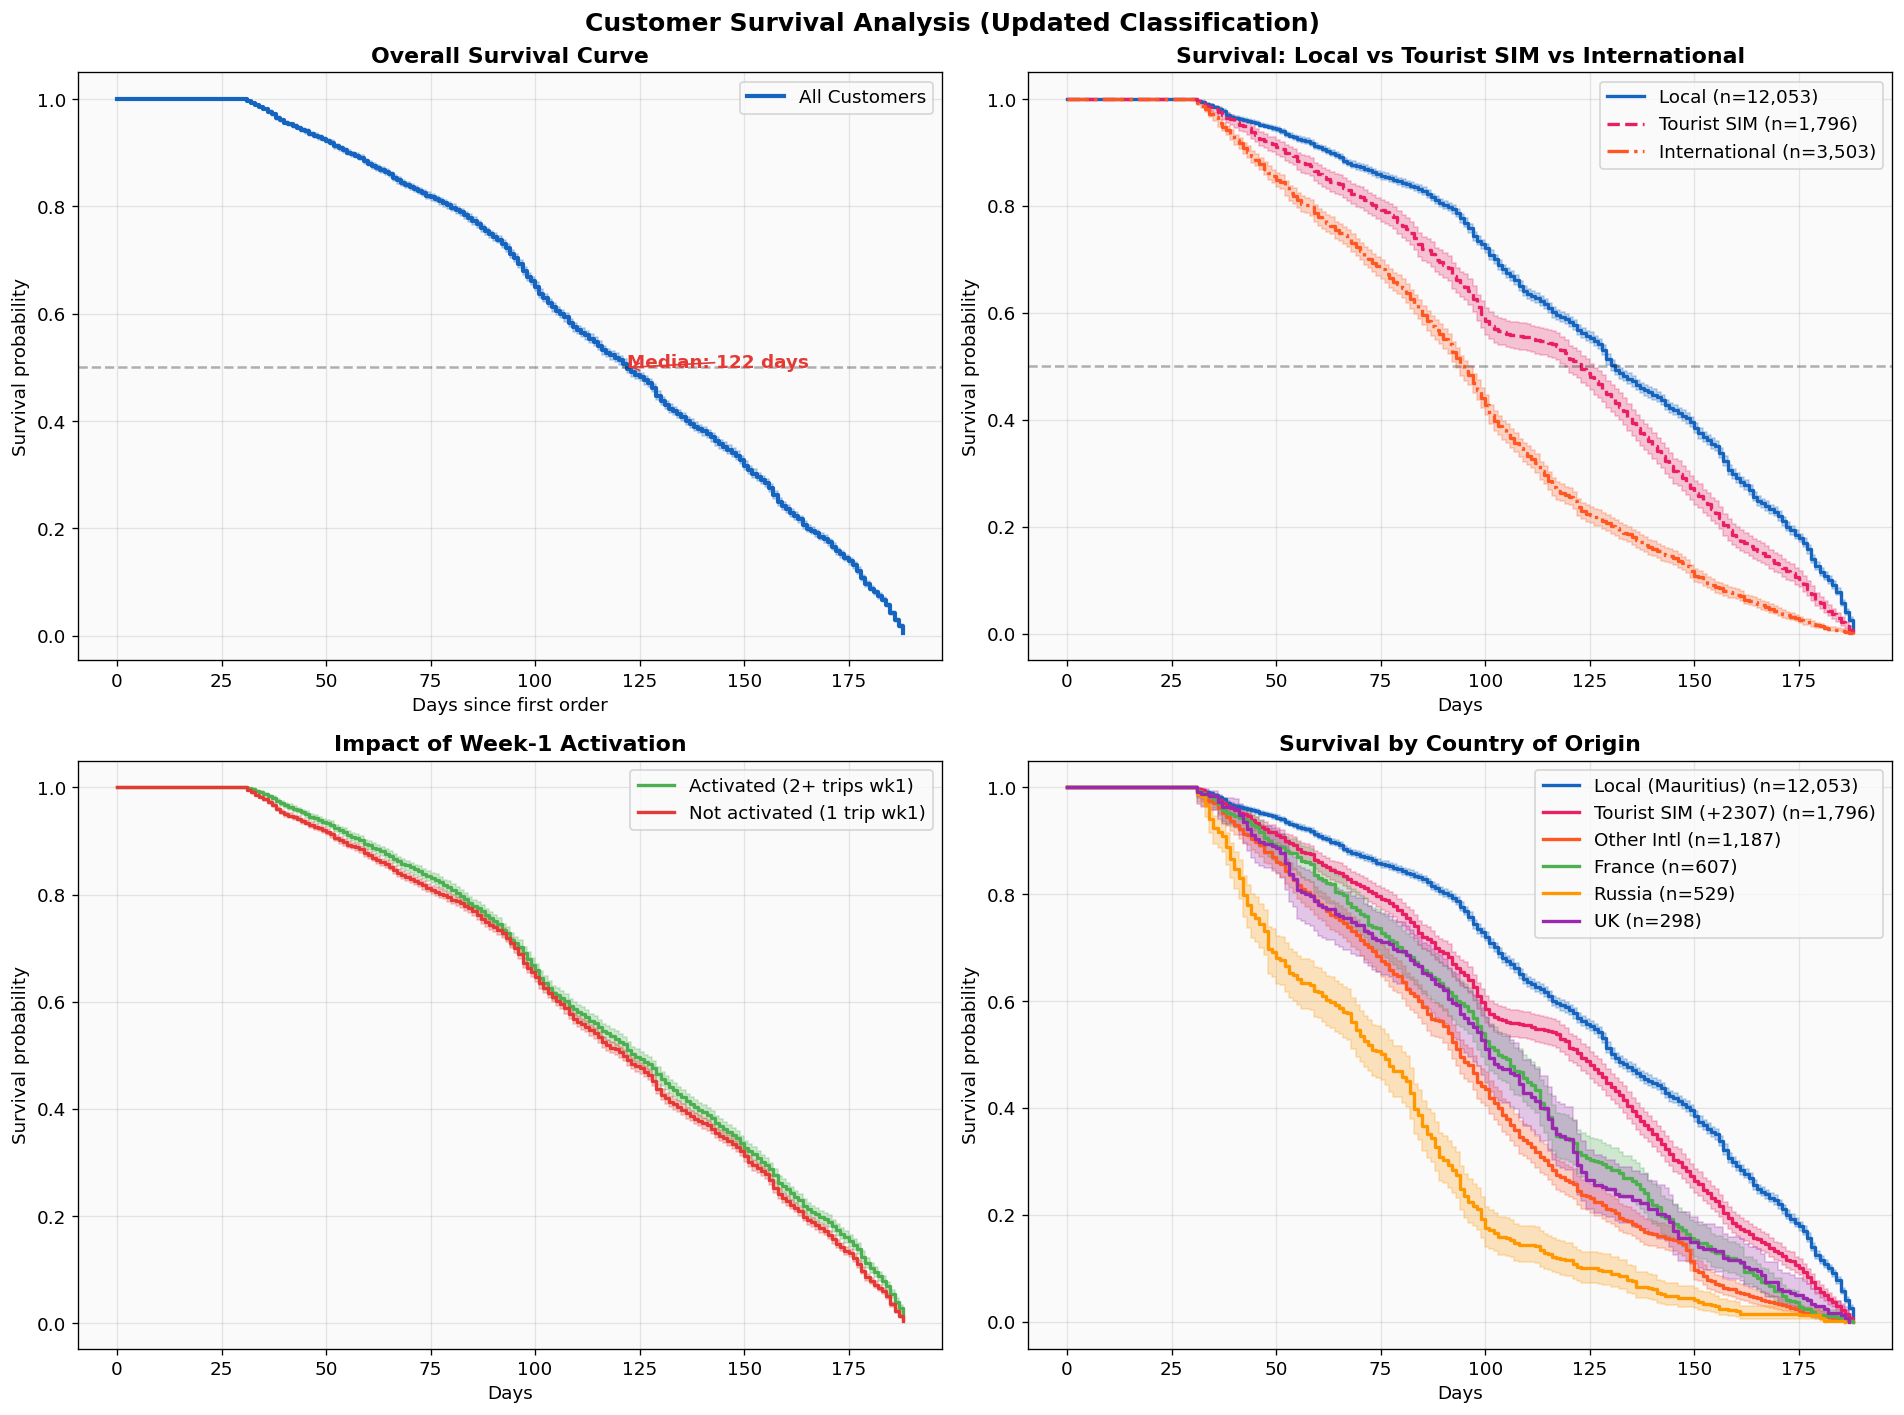

Median survival: 122 days


In [ ]:
surv = user.copy()
surv['T'] = (max_date - surv['first_date']).dt.days
surv['E'] = surv['is_churned']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Survival Analysis (Updated Classification)', fontsize=15, fontweight='bold')

ax = axes[0,0]
kmf = KaplanMeierFitter()
kmf.fit(surv['T'], surv['E'], label='All Customers')
kmf.plot_survival_function(ax=ax, color=C['primary'], linewidth=2.5)
ax.set_title('Overall Survival Curve', fontweight='bold')
ax.set_xlabel('Days since first order'); ax.set_ylabel('Survival probability')
ax.axhline(0.5, color='k', ls='--', alpha=0.3)
median_s = kmf.median_survival_time_
ax.annotate(f'Median: {median_s:.0f} days', xy=(median_s, 0.5),
            fontsize=11, fontweight='bold', color=C['danger'],
            arrowprops=dict(arrowstyle='->', color=C['danger']))

ax = axes[0,1]
for utype, color, ls in [('Local',C['primary'],'-'),('Tourist SIM',C['tourist'],'--'),('International',C['secondary'],'-.')]:
    mask = surv['user_type']==utype
    k = KaplanMeierFitter()
    k.fit(surv.loc[mask,'T'], surv.loc[mask,'E'], label=f'{utype} (n={mask.sum():,})')
    k.plot_survival_function(ax=ax, color=color, linewidth=2, ls=ls)
ax.set_title('Survival: Local vs Tourist SIM vs International', fontweight='bold')
ax.set_xlabel('Days'); ax.set_ylabel('Survival probability')
ax.axhline(0.5, color='k', ls='--', alpha=0.3)

ax = axes[1,0]
for mask, label, color in [(surv['w1_trips']>=2,'Activated (2+ trips wk1)',C['success']),
                            (surv['w1_trips']==1,'Not activated (1 trip wk1)',C['danger'])]:
    k = KaplanMeierFitter()
    k.fit(surv.loc[mask,'T'], surv.loc[mask,'E'], label=label)
    k.plot_survival_function(ax=ax, color=color, linewidth=2)
ax.set_title('Impact of Week-1 Activation', fontweight='bold')
ax.set_xlabel('Days'); ax.set_ylabel('Survival probability')

ax = axes[1,1]
top_countries = user['country'].value_counts().head(6).index
colors_c = [C['primary'],C['tourist'],C['secondary'],C['success'],C['warning'],C['purple']]
for country, color in zip(top_countries, colors_c):
    mask = surv['country']==country
    if mask.sum()>50:
        k = KaplanMeierFitter()
        k.fit(surv.loc[mask,'T'], surv.loc[mask,'E'], label=f'{country} (n={mask.sum():,})')
        k.plot_survival_function(ax=ax, color=color, linewidth=2)
ax.set_title('Survival by Country of Origin', fontweight='bold')
ax.set_xlabel('Days'); ax.set_ylabel('Survival probability')

plt.tight_layout(); plt.show()
print(f"Median survival: {median_s:.0f} days")


### Survival Interpretation

The first month is the main drop-off period. Segment curves differ, so local users and tourist users should not be evaluated with the same retention logic. Tourist activity is shorter by nature and should be interpreted within the visitor stay window.


## 2. Tourist and Local User Comparison

This section compares aggregate behavior across local, tourist-SIM and international users. It helps separate long-term local retention from short-window tourist repeat use.


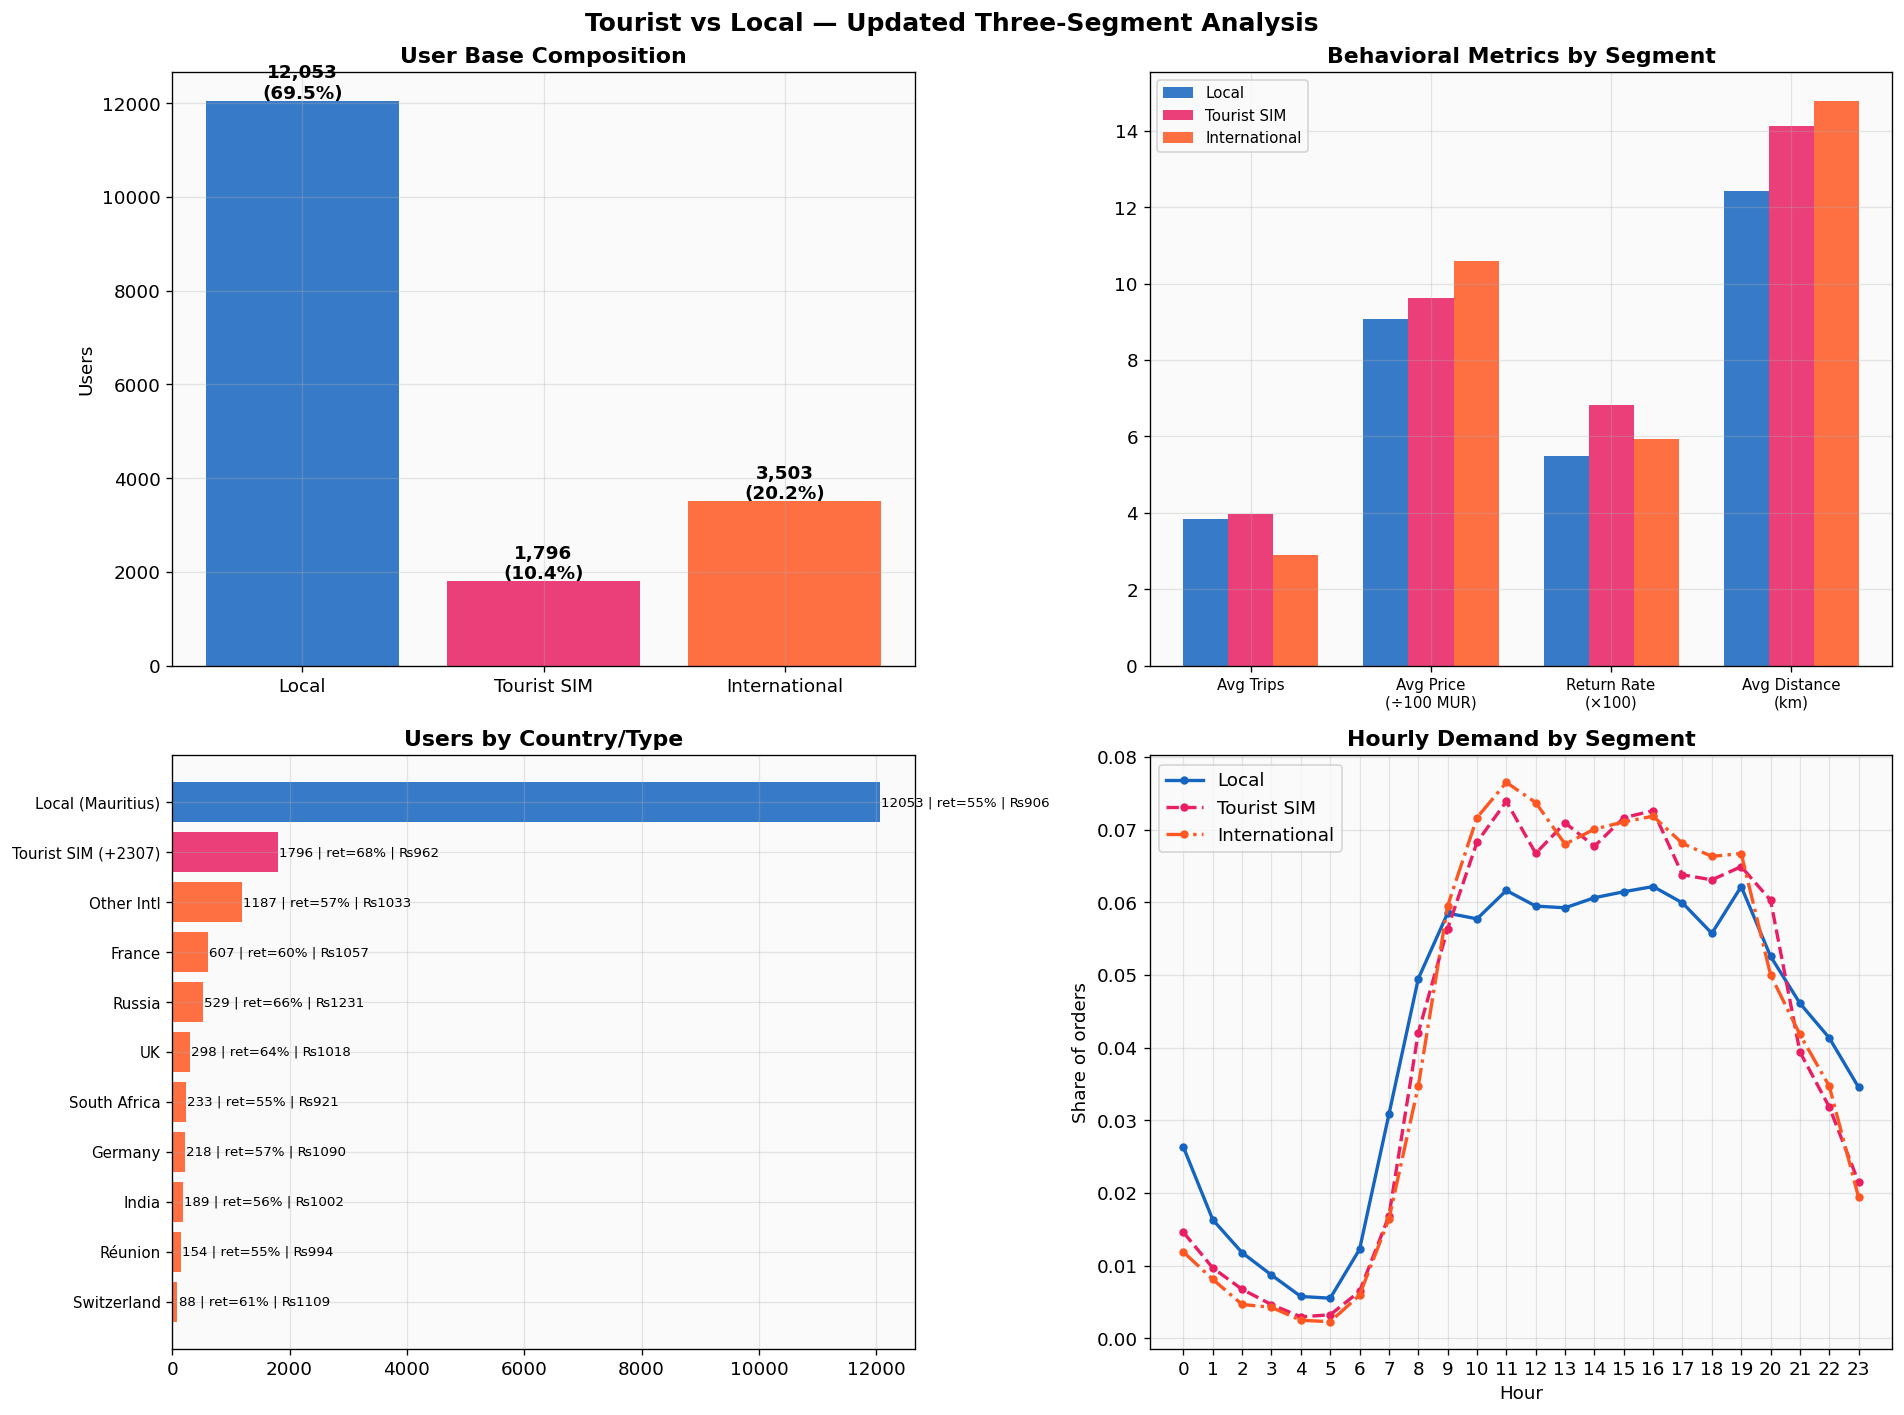

TOURIST VS LOCAL SEGMENT SUMMARY
Local users are the largest group, while tourist SIM and international users behave differently enough to justify separate lifecycle handling.
Tourist SIM users show the highest observed return rate, but also naturally high churn because their stay duration is limited.
International users have lower trip frequency but longer average distances. Exact fare values are omitted from the public output.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Tourist vs Local — Updated Three-Segment Analysis', fontsize=15, fontweight='bold')

ax = axes[0,0]
type_counts = user['user_type'].value_counts().reindex(['Local','Tourist SIM','International'])
colors_3 = [C['primary'], C['tourist'], C['secondary']]
bars = ax.bar(range(3), type_counts.values, color=colors_3, alpha=0.85)
ax.set_xticks(range(3)); ax.set_xticklabels(type_counts.index)
ax.set_title('User Base Composition', fontweight='bold'); ax.set_ylabel('Users')
for b, v in zip(bars, type_counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+50, f'{v:,}\n({v/len(user)*100:.1f}%)', ha='center', fontweight='bold')

ax = axes[0,1]
metrics_data = user.groupby('user_type').agg(
    avg_trips=('trips','mean'), avg_price=('avg_price','mean'),
    return_rate=('returned','mean'), avg_distance=('avg_distance','mean')
).reindex(['Local','Tourist SIM','International'])

x = np.arange(4)
width = 0.25
labels_m = ['Avg Trips','Avg Price\n(÷100 MUR)','Return Rate\n(×100)','Avg Distance\n(km)']
for i, (utype, color) in enumerate(zip(['Local','Tourist SIM','International'], colors_3)):
    vals = [metrics_data.loc[utype,'avg_trips'],
            metrics_data.loc[utype,'avg_price']/100,
            metrics_data.loc[utype,'return_rate']*100/10,
            metrics_data.loc[utype,'avg_distance']]
    ax.bar(x + i*width, vals, width, label=utype, color=color, alpha=0.85)
ax.set_xticks(x + width); ax.set_xticklabels(labels_m, fontsize=9)
ax.set_title('Behavioral Metrics by Segment', fontweight='bold'); ax.legend(fontsize=9)

ax = axes[1,0]
country_stats = user.groupby('country').agg(
    users=('trips','count'), avg_price=('avg_price','mean'),
    return_rate=('returned','mean')).sort_values('users', ascending=False).head(11)
colors_cntry = [C['primary'] if c=='Local (Mauritius)' else C['tourist'] if c=='Tourist SIM (+2307)' else C['secondary']
                for c in country_stats.index]
ax.barh(range(len(country_stats)), country_stats['users'], color=colors_cntry, alpha=0.85)
ax.set_yticks(range(len(country_stats))); ax.set_yticklabels(country_stats.index, fontsize=9)
ax.set_title('Users by Country/Type', fontweight='bold'); ax.invert_yaxis()
for i, (_, r) in enumerate(country_stats.iterrows()):
    ax.text(r['users']+20, i, f"{r['users']:.0f} | ret={r['return_rate']:.0%} | ₨{r['avg_price']:.0f}",
            va='center', fontsize=8)

ax = axes[1,1]
for utype, color, ls in [('Local',C['primary'],'-'),('Tourist SIM',C['tourist'],'--'),('International',C['secondary'],'-.')]:
    phones = user[user['user_type']==utype].index
    h = comp[comp['client_phone'].isin(phones)]['hour'].value_counts().sort_index()
    h_norm = h / h.sum()
    ax.plot(h_norm.index, h_norm.values, color=color, lw=2, ls=ls, marker='o', ms=4, label=utype)
ax.set_title('Hourly Demand by Segment', fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('Share of orders'); ax.set_xticks(range(0,24)); ax.legend()

plt.tight_layout(); plt.show()

print(f"\n{'='*65}")
print(f"{'Metric':22s} {'Local':>12s} {'Tourist SIM':>12s} {'Intl':>12s}")
print(f"{'='*65}")
for utype in ['Local','Tourist SIM','International']:
    u = user[user['user_type']==utype]
print(f"{'Users':22s} {len(user[user['user_type']=='Local']):>12,} "
      f"{len(user[user['user_type']=='Tourist SIM']):>12,} "
      f"{len(user[user['user_type']=='International']):>12,}")
for metric, col, fmt in [('Avg trips','trips','.1f'),('Avg price (MUR)','avg_price','.0f'),
    ('Avg distance (km)','avg_distance','.1f'),('Return rate','returned','.0%'),
    ('Churn rate','is_churned','.0%')]:
    vals = [user[user['user_type']==t][col].mean() for t in ['Local','Tourist SIM','International']]
    print(f"{metric:22s} {vals[0]:>12{fmt}} {vals[1]:>12{fmt}} {vals[2]:>12{fmt}}")


### Segment Interpretation

Tourist-SIM users are a short-window but active segment. Their value comes from repeat use during the stay rather than long-term retention. This finding supports short-validity tourist campaigns rather than generic loyalty mechanics.


## 3. First-to-Second Trip Conversion

The first-trip model tests which early experience factors predict whether a user returns. This is one of the most actionable analyses in the thesis because the first completed interaction is directly controllable by operations.


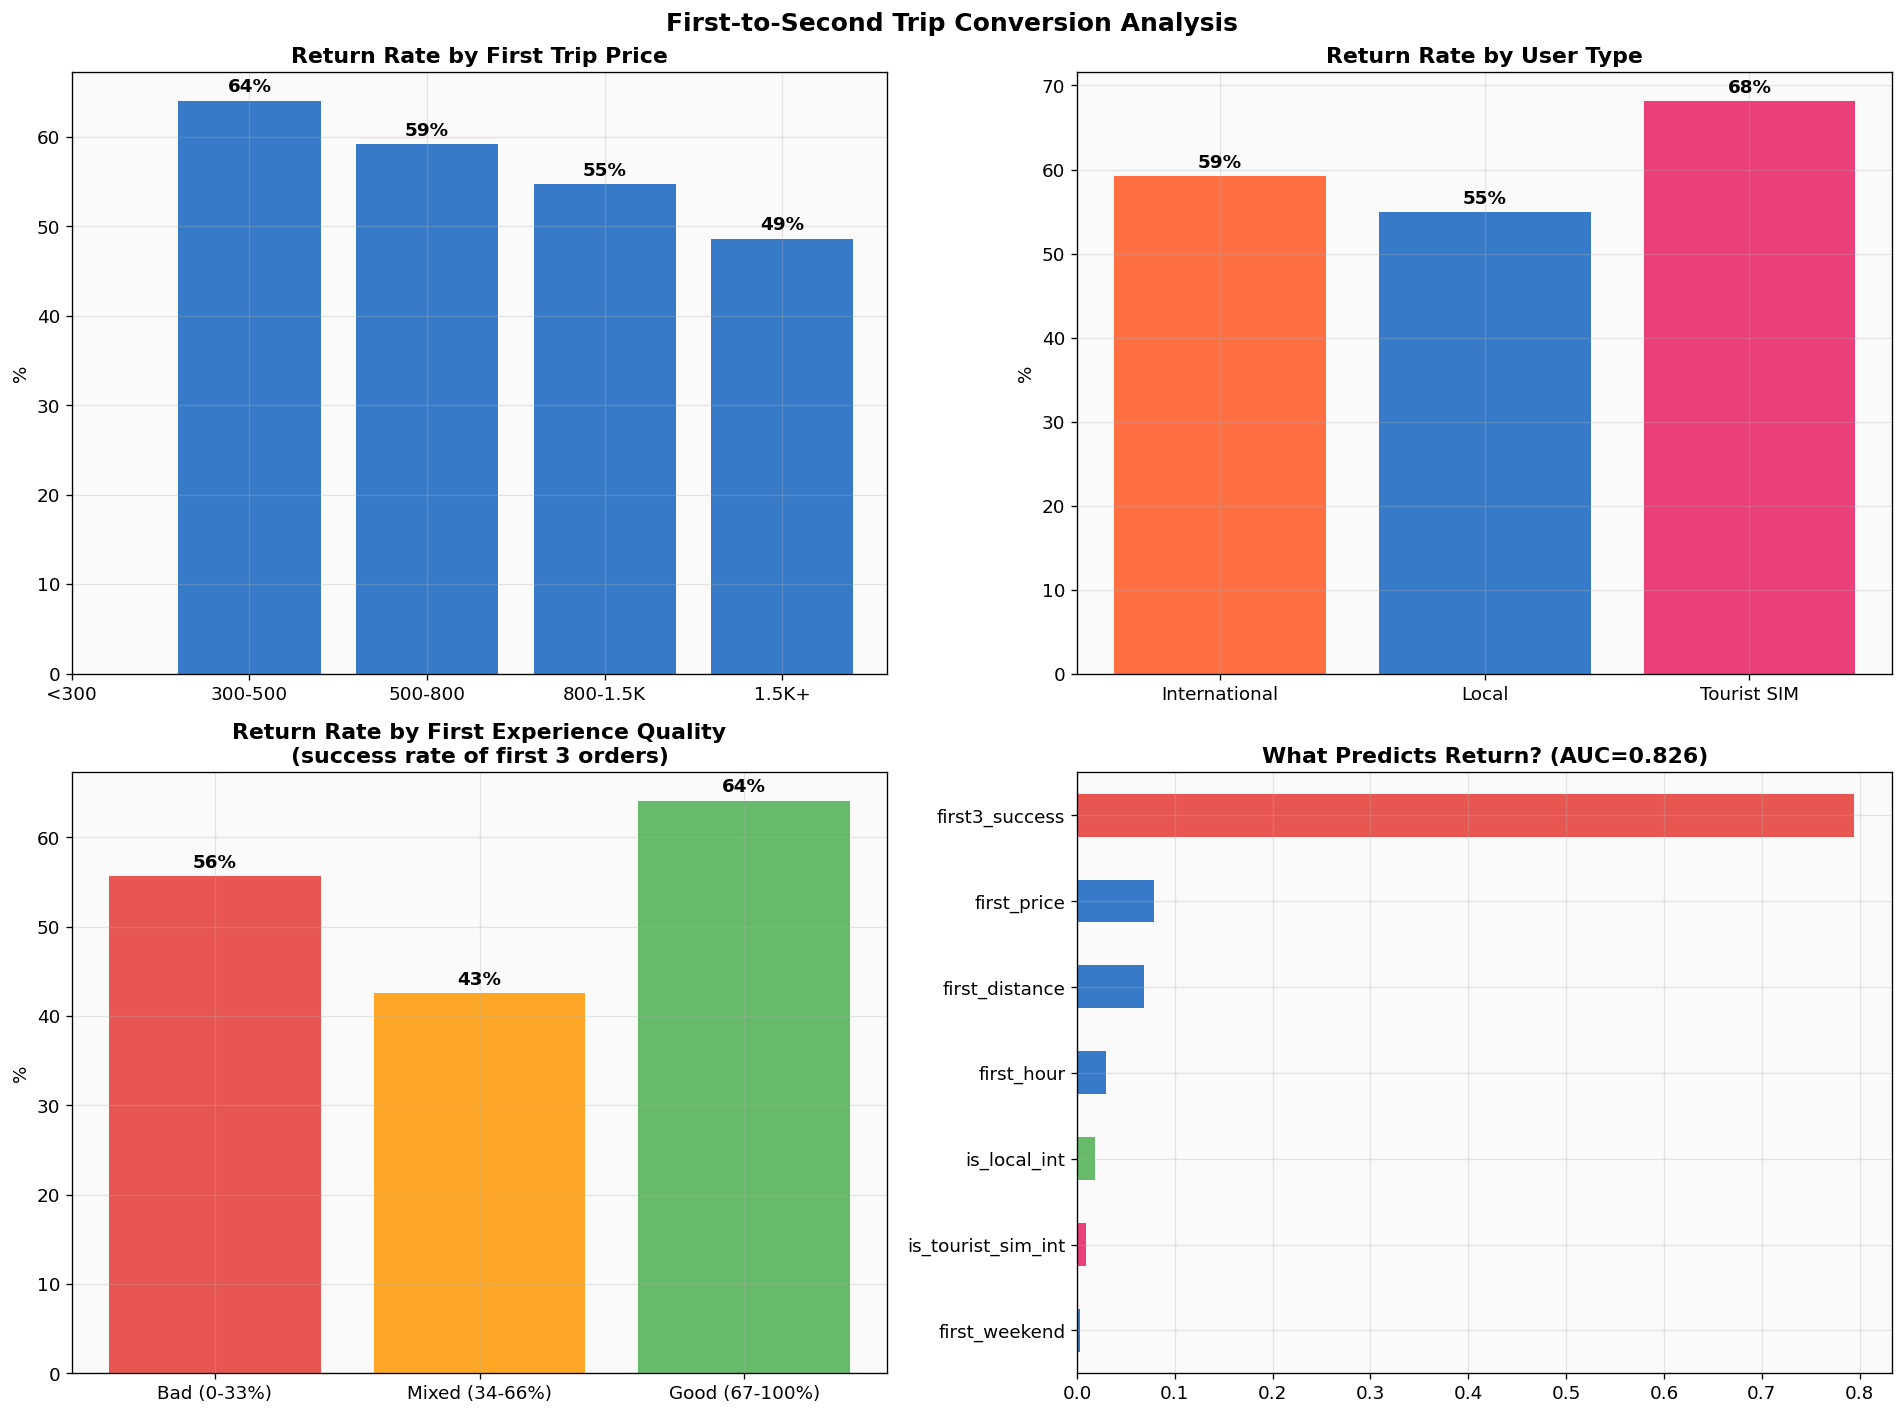


Return Prediction AUC: 0.826
Overall return rate: 57.2%
Local: 55.0%
Tourist SIM: 68.2%
International: 59.2%


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('First-to-Second Trip Conversion Analysis', fontsize=15, fontweight='bold')

ax = axes[0,0]
user['price_bucket'] = pd.cut(user['first_price'], bins=[0,300,500,800,1500,10000],
                                labels=['<300','300-500','500-800','800-1.5K','1.5K+'])
ret_p = user.groupby('price_bucket')['returned'].mean()*100
bars = ax.bar(range(len(ret_p)), ret_p.values, color=C['primary'], alpha=0.85)
ax.set_xticks(range(len(ret_p))); ax.set_xticklabels(ret_p.index)
ax.set_title('Return Rate by First Trip Price', fontweight='bold'); ax.set_ylabel('%')
for b,v in zip(bars,ret_p.values): ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.0f}%', ha='center', fontweight='bold')

ax = axes[0,1]
ret_type = user.groupby('user_type')['returned'].mean()*100
colors_t = [C['secondary'], C['primary'], C['tourist']]
ret_type = ret_type.reindex(['International','Local','Tourist SIM'])
bars = ax.bar(range(3), ret_type.values, color=colors_t, alpha=0.85)
ax.set_xticks(range(3)); ax.set_xticklabels(ret_type.index)
ax.set_title('Return Rate by User Type', fontweight='bold'); ax.set_ylabel('%')
for b,v in zip(bars,ret_type.values): ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.0f}%', ha='center', fontweight='bold')

ax = axes[1,0]
user['first_exp'] = pd.cut(user['first3_success'], bins=[-0.1,0.33,0.66,1.01],
                             labels=['Bad (0-33%)','Mixed (34-66%)','Good (67-100%)'])
ret_e = user.groupby('first_exp')['returned'].mean()*100
bars = ax.bar(range(len(ret_e)), ret_e.values, color=[C['danger'],C['warning'],C['success']], alpha=0.85)
ax.set_xticks(range(len(ret_e))); ax.set_xticklabels(ret_e.index)
ax.set_title('Return Rate by First Experience Quality\n(success rate of first 3 orders)', fontweight='bold')
ax.set_ylabel('%')
for b,v in zip(bars,ret_e.values): ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.0f}%', ha='center', fontweight='bold')

ax = axes[1,1]
feat = ['first_price','first_distance','first_hour','first_weekend','first3_success']
user['is_local_int'] = user['is_local'].astype(int)
user['is_tourist_sim_int'] = user['is_tourist_sim'].astype(int)
feat_full = feat + ['is_local_int','is_tourist_sim_int']
rd = user[feat_full+['returned']].dropna().copy()
rd = rd[(rd['first_distance']>0)&(rd['first_distance']<100)]
X=rd[feat_full]; y=rd['returned']
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
gb = GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42)
gb.fit(Xtr,ytr)
auc = roc_auc_score(yte, gb.predict_proba(Xte)[:,1])
imp = pd.Series(gb.feature_importances_, index=feat_full).sort_values()
colors_imp = [C['danger'] if 'success' in f else C['tourist'] if 'tourist' in f
              else C['success'] if 'local' in f else C['primary'] for f in imp.index]
imp.plot(kind='barh', ax=ax, color=colors_imp, alpha=0.85)
ax.set_title(f'What Predicts Return? (AUC={auc:.3f})', fontweight='bold')

plt.tight_layout(); plt.show()
print(f"\nReturn Prediction AUC: {auc:.3f}")
print(f"Overall return rate: {user['returned'].mean()*100:.1f}%")
print(f"Local: {user[user['is_local']]['returned'].mean()*100:.1f}%")
print(f"Tourist SIM: {user[user['is_tourist_sim']]['returned'].mean()*100:.1f}%")
print(f"International: {user[user['is_international']]['returned'].mean()*100:.1f}%")


### 3.1 Validation Strategy

The first-trip model is validated with cross-validation, tuning and bootstrap confidence intervals. This is necessary because first-trip modelling can be sensitive to sample definition and class balance.


In [ ]:
import gc
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

print('=' * 65)
print('5-FOLD STRATIFIED CROSS-VALIDATION — FIRST-TRIP RETURN')
print('=' * 65)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = cross_val_score(
    GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42),
    X, y, cv=cv, scoring='roc_auc', n_jobs=1
)
print(f"CV AUC: {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")
print(f"Fold scores: {', '.join(f'{s:.4f}' for s in scores_cv)}")
print(f"Single split AUC was: {auc:.4f}")

print(f"\n{'=' * 65}")
print('GRIDSEARCHCV — HYPERPARAMETER TUNING')
print('=' * 65)

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=cv, scoring='roc_auc', n_jobs=1, refit=True
)
grid.fit(X, y)

print(f"Best parameters:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV AUC: {grid.best_score_:.4f} ± {grid.cv_results_['std_test_score'][grid.best_index_]:.4f}")
print(f"Improvement over default: {(grid.best_score_ - scores_cv.mean())*100:+.2f} pp")

print(f"\n{'=' * 65}")
print('BOOTSTRAP 95% CONFIDENCE INTERVAL (200 iterations)')
print('=' * 65)

np.random.seed(42)
n_bootstrap = 200
bootstrap_aucs = []

best_model = grid.best_estimator_

for i in range(n_bootstrap):
    idx = np.random.choice(len(X), size=len(X), replace=True)
    oob_idx = np.setdiff1d(np.arange(len(X)), idx)
    
    if len(oob_idx) < 10:  # skip if too few OOB samples
        continue
    if len(np.unique(y.iloc[oob_idx])) < 2:  # skip if only one class in OOB
        continue
    
    model_b = GradientBoostingClassifier(**grid.best_params_, random_state=i)
    model_b.fit(X.iloc[idx], y.iloc[idx])
    y_pred_b = model_b.predict_proba(X.iloc[oob_idx])[:, 1]
    bootstrap_aucs.append(roc_auc_score(y.iloc[oob_idx], y_pred_b))

bootstrap_aucs = np.array(bootstrap_aucs)
ci_low = np.percentile(bootstrap_aucs, 2.5)
ci_high = np.percentile(bootstrap_aucs, 97.5)

print(f"Bootstrap iterations: {len(bootstrap_aucs)}")
print(f"Mean AUC:    {bootstrap_aucs.mean():.4f}")
print(f"Median AUC:  {np.median(bootstrap_aucs):.4f}")
print(f"95% CI:      [{ci_low:.4f}, {ci_high:.4f}]")
print(f"CI width:    {(ci_high - ci_low)*100:.2f} pp")

print(f"\n{'=' * 65}")
print('FIRST-TRIP MODEL VALIDATION SUMMARY')
print('=' * 65)
print(f"  Sample size:       {len(X)}")
print(f"  Single split AUC:  {auc:.4f}")
print(f"  5-fold CV AUC:     {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")
print(f"  Tuned CV AUC:      {grid.best_score_:.4f} ± {grid.cv_results_['std_test_score'][grid.best_index_]:.4f}")
print(f"  Bootstrap 95% CI:  [{ci_low:.4f}, {ci_high:.4f}]")
print(f"\n  → Despite small sample, model shows {'stable' if (ci_high - ci_low) < 0.15 else 'moderate'} performance")

gc.collect()


5-FOLD STRATIFIED CROSS-VALIDATION — FIRST-TRIP RETURN


CV AUC: 0.8153 ± 0.0036
Fold scores: 0.8187, 0.8174, 0.8085, 0.8152, 0.8171
Single split AUC was: 0.8256

GRIDSEARCHCV — HYPERPARAMETER TUNING


Best parameters:
  learning_rate: 0.05
  max_depth: 3
  min_samples_leaf: 10
  n_estimators: 150
Best CV AUC: 0.8182 ± 0.0035
Improvement over default: +0.29 pp

BOOTSTRAP 95% CONFIDENCE INTERVAL (200 iterations)


Bootstrap iterations: 200
Mean AUC:    0.8162
Median AUC:  0.8165
95% CI:      [0.8071, 0.8246]
CI width:    1.75 pp

FIRST-TRIP MODEL VALIDATION SUMMARY
  Sample size:       16290
  Single split AUC:  0.8256
  5-fold CV AUC:     0.8153 ± 0.0036
  Tuned CV AUC:      0.8182 ± 0.0035
  Bootstrap 95% CI:  [0.8071, 0.8246]

  → Despite small sample, model shows stable performance


### 3.2 Contextual Feature Extension

The extension adds area reliability and driver reliability features known before or at the first trip. The goal is to test whether local service context adds signal beyond the user's own first-trip outcome.


Baseline sample:   16290 rows
Extended sample:   15944 rows  (drops cold-start: no prior driver/area history)



FIRST-TRIP RETURN — BASELINE vs EXTENDED (5-fold CV, same sample)
Baseline (7 feat):  AUC = 0.8183 ± 0.0026  (folds: 0.8148, 0.8193, 0.8179, 0.8167, 0.8225)
Extended (11 feat):  AUC = 0.8261 ± 0.0045  (folds: 0.8195, 0.8305, 0.8232, 0.8256, 0.8314)
Delta:                +0.78 pp  (consistent across folds: +0.47, +1.13, +0.53, +0.88, +0.89 pp)


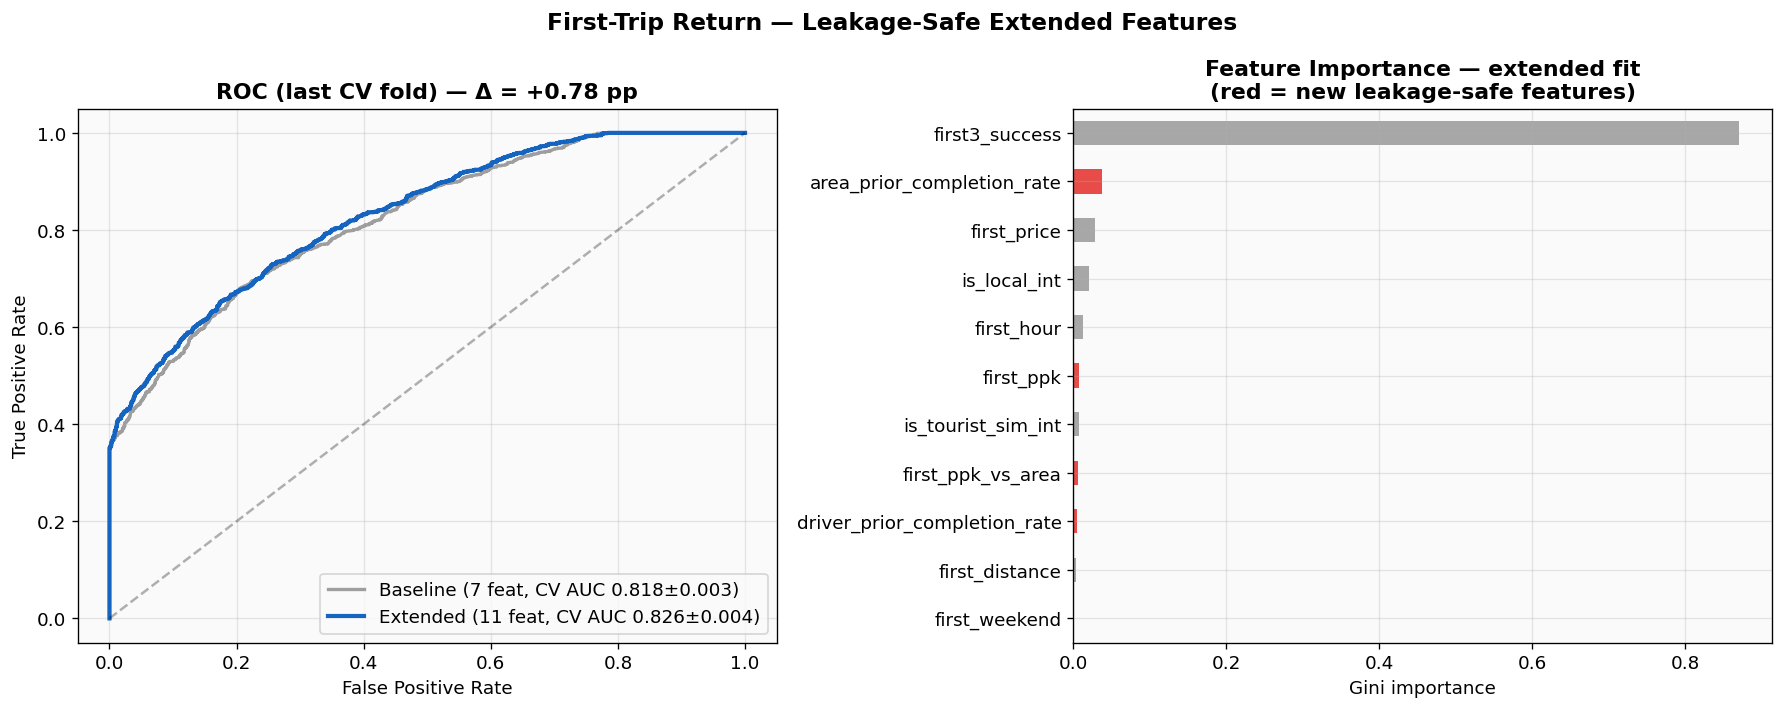


Feature importance (extended fit, sorted):
  first3_success                      0.8704
  area_prior_completion_rate          0.0374  [NEW]
  first_price                         0.0281
  is_local_int                        0.0211
  first_hour                          0.0129
  first_ppk                           0.0077  [NEW]
  is_tourist_sim_int                  0.0074
  first_ppk_vs_area                   0.0065  [NEW]
  driver_prior_completion_rate        0.0045  [NEW]
  first_distance                      0.0039
  first_weekend                       0.0000


In [ ]:
# 3.2 Extended feature set (leakage-safe) - first-trip return
# All new features built strictly from orders with created < client's first_date.
import gc
from sklearn.metrics import roc_curve

AREAS = ["Grand Baie","Flic en Flac","Port Louis","Ebene","Ebène","Curepipe","Quatre Bornes",
         "Tamarin","Riviere Noire","Pereybere","Rose Hill","Vacoas","Beau Bassin",
         "Trou aux Biches","Cap Malheureux","Mahebourg","Belle Mare","Goodlands",
         "Albion","Pointe aux Canonniers","Black River"]
def extract_area(a):
    if pd.isna(a): return "Unknown"
    s = str(a).lower()
    for A in AREAS:
        if A.lower() in s:
            return A.replace("Ebène","Ebene")
    return "Other"

df['area'] = df['pickup_address'].apply(extract_area)

df_s = df.sort_values('created').reset_index(drop=True).copy()
df_s['is_completed_int'] = df_s['is_completed'].astype(int)

drv = df_s.groupby('driver', sort=False)
df_s['drv_prior_total'] = drv.cumcount()
df_s['drv_prior_comp']  = drv['is_completed_int'].cumsum() - df_s['is_completed_int']
df_s['driver_prior_completion_rate'] = np.where(
    df_s['drv_prior_total'] > 0,
    df_s['drv_prior_comp'] / df_s['drv_prior_total'].replace(0, np.nan),
    np.nan
)

ar = df_s.groupby('area', sort=False)
df_s['area_prior_total'] = ar.cumcount()
df_s['area_prior_comp']  = ar['is_completed_int'].cumsum() - df_s['is_completed_int']
df_s['area_prior_completion_rate'] = np.where(
    df_s['area_prior_total'] > 0,
    df_s['area_prior_comp'] / df_s['area_prior_total'].replace(0, np.nan),
    np.nan
)

# expanding median over completed prior rows in the area (correct, leakage-safe).
df_s['ppk'] = np.where(
    (df_s['is_completed_int'] == 1) & (df_s['distance_km'] > 0),
    df_s['price'] / df_s['distance_km'].replace(0, np.nan),
    np.nan
)
# Trim ppk extremes (data-entry errors): same band as §5b
df_s.loc[(df_s['ppk'] < 30) | (df_s['ppk'] > 500), 'ppk'] = np.nan

# Expanding median per area shifted by 1 (so current row is excluded) - leakage-safe
df_s['area_prior_ppk_median'] = (
    df_s.groupby('area')['ppk']
        .transform(lambda s: s.shift(1).expanding(min_periods=20).median())
)

# 3) Identify first completed trip rows per client (same as baseline)
comp_s = df_s[df_s['is_completed'] & (df_s['price'] > 0) & (df_s['distance_km'] > 0)].copy()
first_idx = comp_s.sort_values('created').groupby('client_phone').head(1).index
first_rows = df_s.loc[first_idx, [
    'client_phone',
    'driver_prior_completion_rate',
    'area_prior_completion_rate',
    'area_prior_ppk_median',
    'price', 'distance_km'
]].copy()
first_rows['first_ppk'] = first_rows['price'] / first_rows['distance_km']
first_rows['first_ppk_vs_area'] = first_rows['first_ppk'] / first_rows['area_prior_ppk_median']

new_cols = first_rows.set_index('client_phone')[
    ['first_ppk', 'first_ppk_vs_area',
     'driver_prior_completion_rate', 'area_prior_completion_rate']
]
user_ext = user.join(new_cols, how='left')

# 5) Build extended feature matrix on the SAME sample as baseline X (same filter),
# then drop rows where any new feature is NaN (cold-start drivers/areas without prior history).
feat_base = ['first_price', 'first_distance', 'first_hour', 'first_weekend',
             'first3_success', 'is_local_int', 'is_tourist_sim_int']
feat_new  = ['first_ppk', 'first_ppk_vs_area',
             'driver_prior_completion_rate', 'area_prior_completion_rate']
feat_ext  = feat_base + feat_new

rd_ext = user_ext[feat_ext + ['returned']].dropna().copy()
rd_ext = rd_ext[(rd_ext['first_distance'] > 0) & (rd_ext['first_distance'] < 100)]
print(f"Baseline sample:  {len(rd):>6} rows")
print(f"Extended sample:  {len(rd_ext):>6} rows  (drops cold-start: no prior driver/area history)")

# Re-compute baseline on the SAME extended sample so AUC delta is not driven by sample shift
X_base_same = rd_ext[feat_base]
X_ext_same  = rd_ext[feat_ext]
y_same      = rd_ext['returned']

# 6) 5-fold CV with the same tuned hyperparams from §3.1 (lr=0.05, depth=3, leaf=10, n=150)
best_params = dict(learning_rate=0.05, max_depth=3, min_samples_leaf=10,
                   n_estimators=150, random_state=42)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_auc(Xm, ym):
    aucs = []
    for tr, te in cv5.split(Xm, ym):
        m = GradientBoostingClassifier(**best_params)
        m.fit(Xm.iloc[tr], ym.iloc[tr])
        aucs.append(roc_auc_score(ym.iloc[te], m.predict_proba(Xm.iloc[te])[:, 1]))
    return np.array(aucs)

aucs_base = cv_auc(X_base_same, y_same)
aucs_ext  = cv_auc(X_ext_same,  y_same)

print()
print('=' * 65)
print('FIRST-TRIP RETURN — BASELINE vs EXTENDED (5-fold CV, same sample)')
print('=' * 65)
print(f"Baseline ({len(feat_base)} feat):  AUC = {aucs_base.mean():.4f} ± {aucs_base.std():.4f}  "
      f"(folds: {', '.join(f'{a:.4f}' for a in aucs_base)})")
print(f"Extended ({len(feat_ext)} feat):  AUC = {aucs_ext.mean():.4f} ± {aucs_ext.std():.4f}  "
      f"(folds: {', '.join(f'{a:.4f}' for a in aucs_ext)})")
print(f"Delta:                +{(aucs_ext.mean() - aucs_base.mean())*100:.2f} pp  "
      f"(consistent across folds: {', '.join(f'{(e-b)*100:+.2f}' for b, e in zip(aucs_base, aucs_ext))} pp)")

# 7) Full-fit feature importance + ROC for the figure
m_base = GradientBoostingClassifier(**best_params).fit(X_base_same, y_same)
m_ext  = GradientBoostingClassifier(**best_params).fit(X_ext_same,  y_same)

# Use last fold's hold-out for ROC visualization
last_tr, last_te = list(cv5.split(X_ext_same, y_same))[-1]
fpr_b, tpr_b, _ = roc_curve(y_same.iloc[last_te],
                            GradientBoostingClassifier(**best_params)
                              .fit(X_base_same.iloc[last_tr], y_same.iloc[last_tr])
                              .predict_proba(X_base_same.iloc[last_te])[:, 1])
fpr_e, tpr_e, _ = roc_curve(y_same.iloc[last_te],
                            GradientBoostingClassifier(**best_params)
                              .fit(X_ext_same.iloc[last_tr], y_same.iloc[last_tr])
                              .predict_proba(X_ext_same.iloc[last_te])[:, 1])

# 8) Plot - 2 panels: ROC + feature importance with new features highlighted
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('First-Trip Return — Leakage-Safe Extended Features', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(fpr_b, tpr_b, color=C['gray'], lw=2,
        label=f'Baseline (7 feat, CV AUC {aucs_base.mean():.3f}±{aucs_base.std():.3f})')
ax.plot(fpr_e, tpr_e, color=C['primary'], lw=2.5,
        label=f'Extended (11 feat, CV AUC {aucs_ext.mean():.3f}±{aucs_ext.std():.3f})')
ax.plot([0, 1], [0, 1], '--', color='black', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC (last CV fold) — Δ = +{(aucs_ext.mean()-aucs_base.mean())*100:.2f} pp', fontweight='bold')
ax.legend(loc='lower right')

ax = axes[1]
imp = pd.Series(m_ext.feature_importances_, index=feat_ext).sort_values()
new_set = set(feat_new)
colors_imp = [C['danger'] if f in new_set else C['gray'] for f in imp.index]
imp.plot(kind='barh', ax=ax, color=colors_imp, alpha=0.9)
ax.set_title('Feature Importance — extended fit\n(red = new leakage-safe features)', fontweight='bold')
ax.set_xlabel('Gini importance')

plt.tight_layout()
plt.savefig('figures/fig_first_trip_extended_features.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Feature importance (extended fit, sorted):')
for f, v in imp.sort_values(ascending=False).items():
    tag = '  [NEW]' if f in new_set else ''
    print(f"  {f:35s} {v:.4f}{tag}")

gc.collect()


### First-Trip Interpretation

First-trip outcome is the strongest retention signal. The business implication is clear: protect the first ride, assign reliable drivers where possible and recover quickly if the first attempt fails. This result anchors the activation recommendations in Chapter 4.


## 4. Cohort Retention Analysis

Monthly cohorts show how retention changes after the first order month. The output complements survival analysis by showing period-level retention rather than individual survival time.


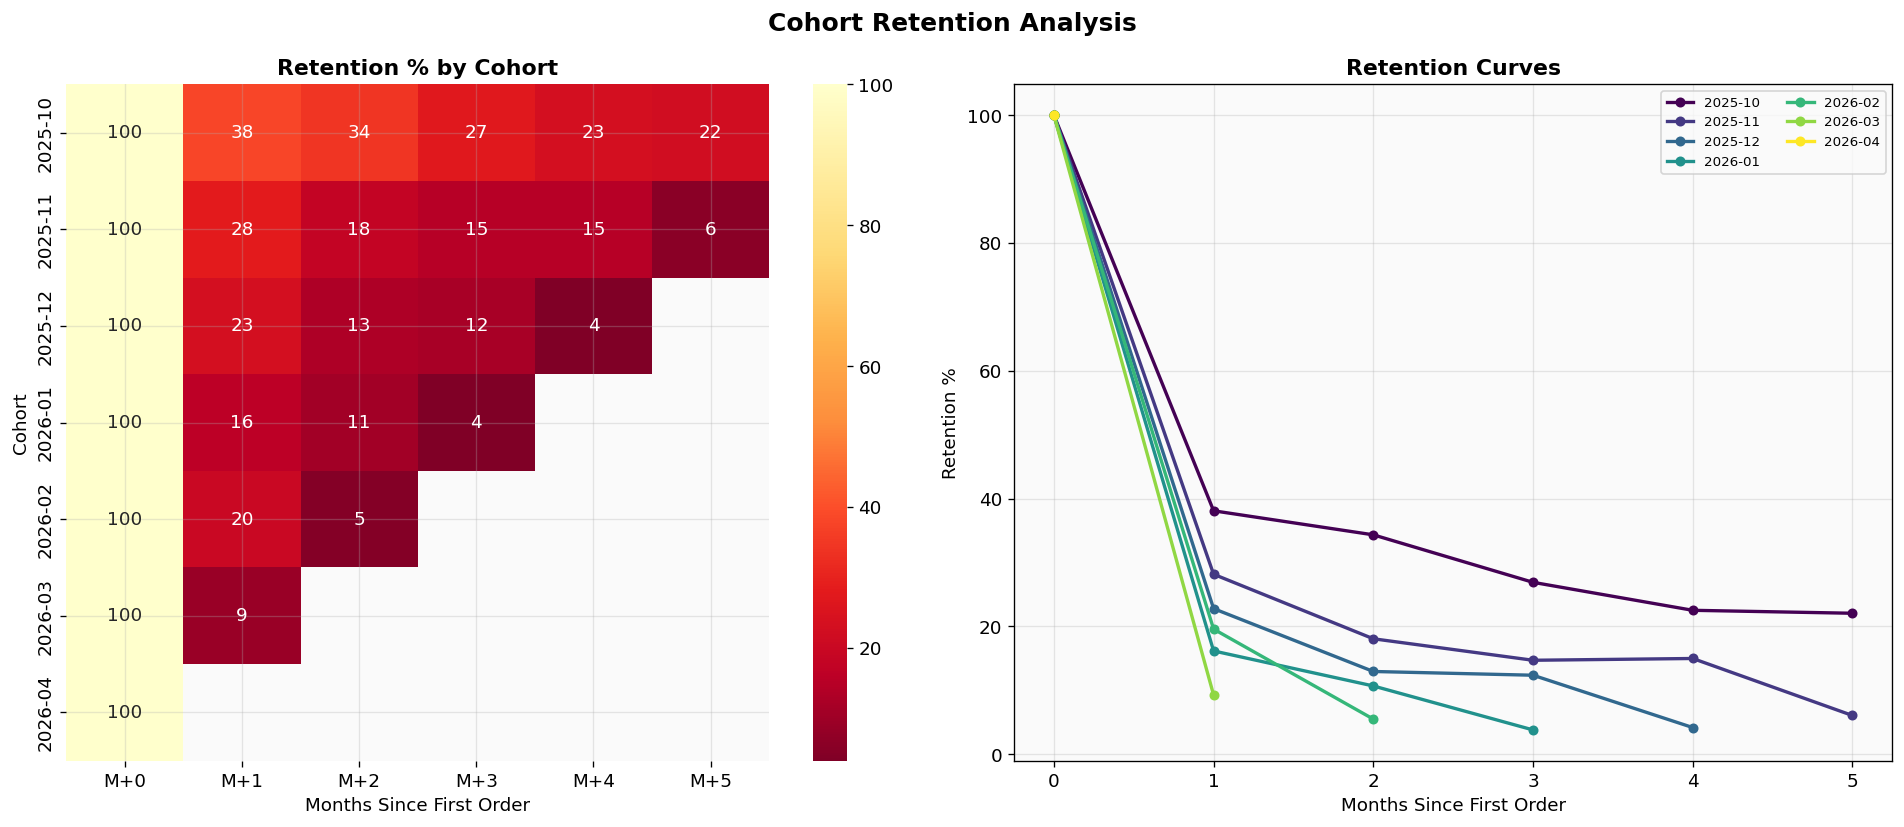

M+1 avg retention: 22.3%
M+2 avg retention: 16.3%
M+3 avg retention: 14.4%


In [ ]:
user['cohort'] = user['first_date'].dt.to_period('M')
comp_c = comp.merge(user[['cohort']], left_on='client_phone', right_index=True)
comp_c['order_period'] = comp_c['date'].dt.to_period('M')

cohort_act = comp_c.groupby(['cohort','order_period'])['client_phone'].nunique().reset_index()
cohort_act.columns = ['cohort','order_period','users']
cohort_act['months_since'] = cohort_act.apply(
    lambda r: (r['order_period'].year-r['cohort'].year)*12 + r['order_period'].month-r['cohort'].month, axis=1)

retention = cohort_act.pivot(index='cohort', columns='months_since', values='users')
retention_pct = retention.div(retention[0], axis=0) * 100
valid = retention_pct.loc[retention[0]>=100].iloc[:,:6]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Cohort Retention Analysis', fontsize=15, fontweight='bold')

ax = axes[0]
sns.heatmap(valid.round(0), annot=True, fmt='.0f', cmap='YlOrRd_r', ax=ax,
            yticklabels=[str(c) for c in valid.index],
            xticklabels=[f'M+{i}' for i in valid.columns])
ax.set_title('Retention % by Cohort', fontweight='bold')
ax.set_xlabel('Months Since First Order'); ax.set_ylabel('Cohort')

ax = axes[1]
for (cohort, row), color in zip(valid.iterrows(), plt.cm.viridis(np.linspace(0,1,len(valid)))):
    vals = row.dropna()
    ax.plot(vals.index, vals.values, marker='o', color=color, lw=2, label=str(cohort), ms=5)
ax.set_title('Retention Curves', fontweight='bold')
ax.set_xlabel('Months Since First Order'); ax.set_ylabel('Retention %')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout(); plt.show()
print(f"M+1 avg retention: {valid[1].mean():.1f}%")
if 2 in valid.columns: print(f"M+2 avg retention: {valid[2].mean():.1f}%")
if 3 in valid.columns: print(f"M+3 avg retention: {valid[3].mean():.1f}%")


### Cohort Interpretation

Most loss happens between the first and second month. Later retention stabilizes at a lower but more loyal base, which supports early lifecycle interventions rather than delayed reactivation only.


## 5. Tourist Stay Duration and Seasonality

Tourist activity is evaluated over the likely visitor stay window. A standard 30-day churn definition can misclassify tourist behavior, so this section checks active duration and seasonal concentration separately.


Tourist SIM: 84.5% stay <=14 days, 90.3% stay <=28 days
International: 93.6% stay <=14 days, 96.9% stay <=28 days


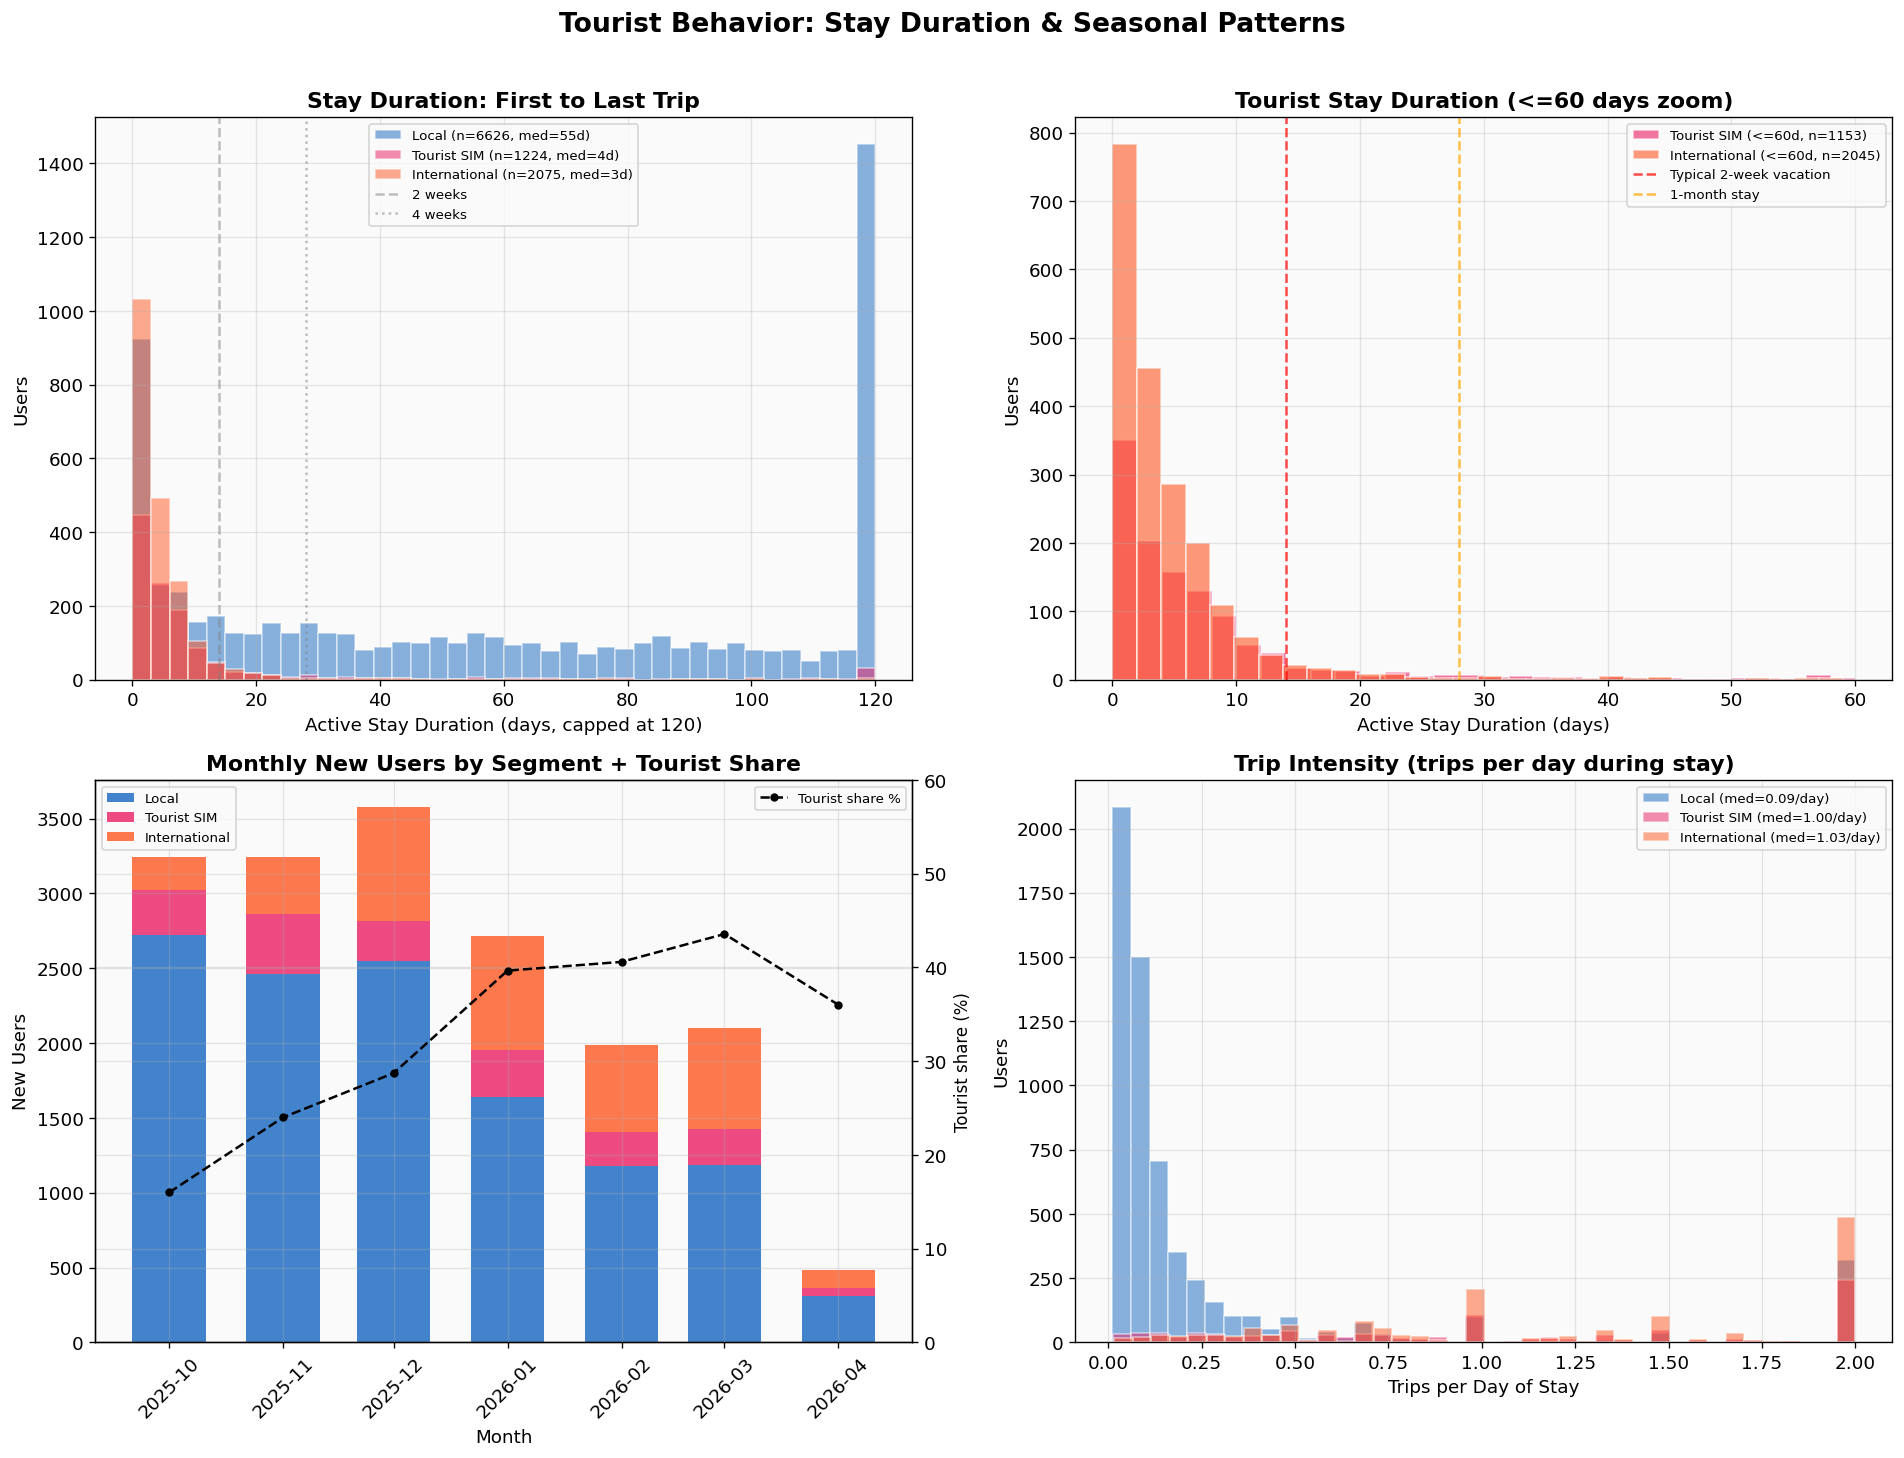


TOURIST BEHAVIOR SUMMARY

Local:
  Total users: 12,053
  Single-trip users: 5,427 (45.0%)
  Multi-trip users: 6,626
  Median stay: 55 days
  Mean stay: 65 days
  <=14 days: 26.4%
  <=28 days: 36.0%
  <=60 days: 53.7%
  Median trips: 2
  Avg trips/day (multi-trip): 0.10

Tourist SIM:
  Total users: 1,796
  Single-trip users: 572 (31.8%)
  Multi-trip users: 1,224
  Median stay: 4 days
  Mean stay: 13 days
  <=14 days: 84.5%
  <=28 days: 90.3%
  <=60 days: 94.2%
  Median trips: 2
  Avg trips/day (multi-trip): 1.12

International:
  Total users: 3,503
  Single-trip users: 1,428 (40.8%)
  Multi-trip users: 2,075
  Median stay: 3 days
  Mean stay: 6 days
  <=14 days: 93.6%
  <=28 days: 96.9%
  <=60 days: 98.6%
  Median trips: 2
  Avg trips/day (multi-trip): 1.57

Monthly tourist share range: 16.0% - 43.6%
Peak tourist months:
  2026-03: 43.6% tourist
  2026-02: 40.6% tourist
  2026-01: 39.7% tourist


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Tourist Behavior: Stay Duration & Seasonal Patterns', 
             fontsize=16, fontweight='bold', y=1.01)

ax = axes[0, 0]
for utype, color, label in [('Local', C['primary'], 'Local'),
                              ('Tourist SIM', C['tourist'], 'Tourist SIM'),
                              ('International', C['secondary'], 'International')]:
    subset = user[user['user_type'] == utype]
    multi = subset[subset['trips'] >= 2]['tenure_days']
    if len(multi) > 0:
        ax.hist(multi.clip(upper=120), bins=40, alpha=0.5, label=f'{label} (n={len(multi)}, med={multi.median():.0f}d)',
                color=color, edgecolor='white')
ax.set_xlabel('Active Stay Duration (days, capped at 120)')
ax.set_ylabel('Users')
ax.set_title('Stay Duration: First to Last Trip', fontweight='bold')
ax.axvline(14, color='gray', linestyle='--', alpha=0.5, label='2 weeks')
ax.axvline(28, color='gray', linestyle=':', alpha=0.5, label='4 weeks')
ax.legend(fontsize=8)

ax = axes[0, 1]
for utype, color in [('Tourist SIM', C['tourist']), ('International', C['secondary'])]:
    subset = user[(user['user_type'] == utype) & (user['trips'] >= 2)]
    stay = subset['tenure_days']
    short_stay = stay[stay <= 60]
    if len(short_stay) > 0:
        ax.hist(short_stay, bins=30, alpha=0.6, label=f'{utype} (<=60d, n={len(short_stay)})',
                color=color, edgecolor='white')
        pct_under_14 = (stay <= 14).mean() * 100
        pct_under_28 = (stay <= 28).mean() * 100
        print(f'{utype}: {pct_under_14:.1f}% stay <=14 days, {pct_under_28:.1f}% stay <=28 days')
ax.axvline(14, color='red', linestyle='--', alpha=0.7, label='Typical 2-week vacation')
ax.axvline(28, color='orange', linestyle='--', alpha=0.7, label='1-month stay')
ax.set_xlabel('Active Stay Duration (days)')
ax.set_ylabel('Users')
ax.set_title('Tourist Stay Duration (<=60 days zoom)', fontweight='bold')
ax.legend(fontsize=8)

ax = axes[1, 0]
monthly_type = user.groupby([user['first_date'].dt.to_period('M'), 'user_type']).size().unstack(fill_value=0)
monthly_type.index = monthly_type.index.to_timestamp()
for col in ['Tourist SIM', 'International', 'Local']:
    if col not in monthly_type.columns:
        monthly_type[col] = 0
monthly_type['total'] = monthly_type.sum(axis=1)
monthly_type['tourist_share'] = (monthly_type['Tourist SIM'] + monthly_type['International']) / monthly_type['total'] * 100

ax.bar(monthly_type.index, monthly_type['Local'], label='Local', color=C['primary'], alpha=0.8, width=20)
ax.bar(monthly_type.index, monthly_type['Tourist SIM'], 
       bottom=monthly_type['Local'], label='Tourist SIM', color=C['tourist'], alpha=0.8, width=20)
ax.bar(monthly_type.index, monthly_type['International'],
       bottom=monthly_type['Local'] + monthly_type['Tourist SIM'],
       label='International', color=C['secondary'], alpha=0.8, width=20)
ax2 = ax.twinx()
ax2.plot(monthly_type.index, monthly_type['tourist_share'], 'k--o', markersize=4, label='Tourist share %')
ax2.set_ylabel('Tourist share (%)', fontsize=10)
ax2.set_ylim(0, 60)
ax.set_xlabel('Month')
ax.set_ylabel('New Users')
ax.set_title('Monthly New Users by Segment + Tourist Share', fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 1]
for utype, color in [('Local', C['primary']), ('Tourist SIM', C['tourist']), ('International', C['secondary'])]:
    subset = user[(user['user_type'] == utype) & (user['trips'] >= 2) & (user['tenure_days'] > 0)]
    intensity = subset['trips'] / subset['tenure_days']
    ax.hist(intensity.clip(upper=2), bins=40, alpha=0.5, label=f'{utype} (med={intensity.median():.2f}/day)',
            color=color, edgecolor='white')
ax.set_xlabel('Trips per Day of Stay')
ax.set_ylabel('Users')
ax.set_title('Trip Intensity (trips per day during stay)', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig_tourist_duration_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print('TOURIST BEHAVIOR SUMMARY')
print('='*60)
for utype in ['Local', 'Tourist SIM', 'International']:
    s = user[user['user_type'] == utype]
    multi = s[s['trips'] >= 2]
    print(f'\n{utype}:')
    print(f'  Total users: {len(s):,}')
    print(f'  Single-trip users: {(s["trips"]==1).sum():,} ({(s["trips"]==1).mean()*100:.1f}%)')
    if len(multi) > 0:
        print(f'  Multi-trip users: {len(multi):,}')
        print(f'  Median stay: {multi["tenure_days"].median():.0f} days')
        print(f'  Mean stay: {multi["tenure_days"].mean():.0f} days')
        print(f'  <=14 days: {(multi["tenure_days"]<=14).mean()*100:.1f}%')
        print(f'  <=28 days: {(multi["tenure_days"]<=28).mean()*100:.1f}%')
        print(f'  <=60 days: {(multi["tenure_days"]<=60).mean()*100:.1f}%')
        print(f'  Median trips: {s["trips"].median():.0f}')
        print(f'  Avg trips/day (multi-trip): {(multi["trips"]/multi["tenure_days"].clip(lower=1)).median():.2f}')

print(f'\nMonthly tourist share range: {monthly_type["tourist_share"].min():.1f}% - {monthly_type["tourist_share"].max():.1f}%')
peak_months = monthly_type.nlargest(3, 'tourist_share')[['tourist_share']]
print(f'Peak tourist months:')
for idx, row in peak_months.iterrows():
    print(f'  {idx.strftime("%Y-%m")}: {row["tourist_share"]:.1f}% tourist')


### Tourist-Behavior Interpretation

Tourist activity is concentrated in a short period. Short-validity incentives, airport triggers and hotel-area visibility match this behavior better than long loyalty cycles. This distinction is used in the tourist-strategy recommendation.


## 6. Lifecycle Summary

This notebook provides the customer-lifecycle evidence for the thesis. It explains when users stop returning, how first-trip experience predicts repeat behavior and why tourist users should be interpreted differently from local users.

Main conclusions:

- Survival and cohort curves show that the largest retention loss happens early in the customer lifecycle.
- First-trip outcome is the strongest actionable signal for whether a user returns.
- Area and driver reliability add useful context, which means first-trip retention is connected to operational quality, not only to marketing.
- Tourist-SIM users behave as a short-window active segment, so standard long-term churn logic is not fully appropriate for them.
- Cohort retention stabilizes after the steep early drop, suggesting that early activation is more important than late reactivation alone.

Limitations:

- Tourist behavior is naturally time-limited by stay duration, so tourist churn should not be interpreted the same way as local churn.
- First-trip modelling depends on the definition of return window and available early-experience features.
- Outputs are aggregate only; individual phone-level records are not exposed.

Thesis use:

- Chapter 3 uses this notebook for first-to-second trip prediction, survival analysis, cohort retention and customer value context.
- Chapter 4 uses it to justify first-trip protection, early repeat nudges and tourist-specific lifecycle recommendations.
